# 1. Single Linear Regression - Video Game Sales
## (Using one feature to predict a continuous numerical target)
## https://www.kaggle.com/datasets/ulrikthygepedersen/video-games-sales

In [158]:
#Import Statments
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [159]:
# Loading video game sales data
df_VideoGame = pd.read_csv('video_games_sales.csv')

# Visualizing the dataframe
df_VideoGame

,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


## Let's see if we can use a subset of this data to predict the target variable: global_sales

In [160]:
# Exctracting Features from the original df_VideoGame Dataset
df_VideoGameFeatureSubset = df_VideoGame[['platform', 'year', 'genre', 'publisher','na_sales', 'global_sales']]

# Dropping null values from the dataset
df_VideoGameFeatureSubset.dropna(inplace=True) # Should have imuted, and not dropped
df_VideoGameFeatureSubset.isnull().sum()

/tmp/ipykernel_1678549/3848451090.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_VideoGameFeatureSubset.dropna(inplace=True) # Should have imuted, and not dropped


platform        0
year            0
genre           0
publisher       0
na_sales        0
global_sales    0
dtype: int64

In [161]:
# Initialize the labelencoder object
le_videogame = LabelEncoder()

# Save the unencoded feature platform (In case you want to decode later)
df_VideoGame_decoded_platform = df_VideoGameFeatureSubset['platform']

# Override the original platform feature with the label encoded feature
df_VideoGameFeatureSubset['platform'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['platform'])

# Print out the decoded series, platform
df_VideoGame_decoded_platform

/tmp/ipykernel_1678549/3575130277.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_VideoGameFeatureSubset['platform'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['platform'])


0        Wii
1        NES
2        Wii
3        Wii
4         GB
        ... 
16593    GBA
16594     GC
16595    PS2
16596     DS
16597    GBA
Name: platform, Length: 16291, dtype: object

In [162]:
# Save the unencoded feature genre (In case you want to decode later)
df_VideoGame_decoded_genre = df_VideoGameFeatureSubset['genre']

# Override the original genre feature with the label encoded feature
df_VideoGameFeatureSubset['genre'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['genre'])

# Print out the decoded series, genre
df_VideoGame_decoded_genre

/tmp/ipykernel_1678549/3503678093.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_VideoGameFeatureSubset['genre'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['genre'])


0              Sports
1            Platform
2              Racing
3              Sports
4        Role-Playing
             ...     
16593        Platform
16594         Shooter
16595          Racing
16596          Puzzle
16597        Platform
Name: genre, Length: 16291, dtype: object

In [163]:
# Save the unencoded feature publisher (In case you want to decode later)
df_VideoGame_decoded_publisher = df_VideoGameFeatureSubset['publisher']

# Override the original publisher feature with the label encoded feature
df_VideoGameFeatureSubset['publisher'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['publisher'])

# Print out the decoded series, publisher
df_VideoGame_decoded_publisher

/tmp/ipykernel_1678549/109776527.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_VideoGameFeatureSubset['publisher'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['publisher'])


0          Nintendo
1          Nintendo
2          Nintendo
3          Nintendo
4          Nintendo
            ...    
16593         Kemco
16594    Infogrames
16595    Activision
16596      7G//AMES
16597       Wanadoo
Name: publisher, Length: 16291, dtype: object

In [164]:
# Feel free to uncomment the chart below, may take a little while to output though
#sns.pairplot(df_VideoGameFeatureSubset.drop('global_sales', axis=1), kind='kde')

In [165]:
# View the labelencoded dataframe
df_VideoGameFeatureSubset

,platform,year,genre,publisher,na_sales,global_sales
0,26,2006.0,10,359,41.49,82.74
1,11,1985.0,4,359,29.08,40.24
2,26,2008.0,6,359,15.85,35.82
3,26,2009.0,10,359,15.75,33.00
4,5,1996.0,7,359,11.27,31.37
...,...,...,...,...,...,...
16593,6,2002.0,4,269,0.01,0.01
16594,7,2003.0,8,241,0.01,0.01
16595,16,2008.0,6,21,0.00,0.01
16596,4,2010.0,5,8,0.00,0.01


In [166]:
# Normailze platform, year, genre, and publisher
mm_scaler = MinMaxScaler(feature_range=(-1, 1))

df_VideoGameFeatureSubset[['platform', 'year', 'genre', 'publisher']] = mm_scaler.fit_transform(df_VideoGameFeatureSubset[['platform', 'year', 'genre', 'publisher']])
df_VideoGameFeatureSubset

/tmp/ipykernel_1678549/2534807158.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_VideoGameFeatureSubset[['platform', 'year', 'genre', 'publisher']] = mm_scaler.fit_transform(df_VideoGameFeatureSubset[['platform', 'year', 'genre', 'publisher']])


,platform,year,genre,publisher,na_sales,global_sales
0,0.733333,0.30,0.818182,0.248696,41.49,82.74
1,-0.266667,-0.75,-0.272727,0.248696,29.08,40.24
2,0.733333,0.40,0.090909,0.248696,15.85,35.82
3,0.733333,0.45,0.818182,0.248696,15.75,33.00
4,-0.666667,-0.20,0.272727,0.248696,11.27,31.37
...,...,...,...,...,...,...
16593,-0.600000,0.10,-0.272727,-0.064348,0.01,0.01
16594,-0.533333,0.15,0.454545,-0.161739,0.01,0.01
16595,0.066667,0.40,0.090909,-0.926957,0.00,0.01
16596,-0.733333,0.50,-0.090909,-0.972174,0.00,0.01


In [167]:
# Create a pairplot for the normalized data, columns_to_manipulate, use kde for the kind
#sns.pairplot(df_VideoGameFeatureSubset, kind='kde')

In [168]:
# Save Checkpoint
df_VideoGameFeatureSubset.to_csv('Game_Data_Cleaned.csv')

In [169]:
# Load the cleaned video game sales data into a dataframe
df_VideoGameCleaned = pd.read_csv('Game_Data_Cleaned.csv')

# Remove the column named 'Unnamed: 0'
df_VideoGameCleaned = df_VideoGameCleaned.drop(columns=['Unnamed: 0'])

# print out the dataframe
df_VideoGameCleaned.head()

,platform,year,genre,publisher,na_sales,global_sales
0,0.733333,0.30,0.818182,0.248696,41.49,82.74
1,-0.266667,-0.75,-0.272727,0.248696,29.08,40.24
2,0.733333,0.40,0.090909,0.248696,15.85,35.82
3,0.733333,0.45,0.818182,0.248696,15.75,33.00
4,-0.666667,-0.20,0.272727,0.248696,11.27,31.37


In [170]:
# use the pandas dataframe function called .corr() to quickly check which features most closely 'relate' to the target variable, higher is better
df_VideoGameCleaned.corr()
# 1.0 is a perfect correlation but that means the feature is the same

,platform,year,genre,publisher,na_sales,global_sales
platform,1.000000,0.167648,0.026665,-0.017938,0.041976,0.027929
year,0.167648,1.000000,-0.125366,0.029802,-0.091285,-0.074647
genre,0.026665,-0.125366,1.000000,-0.051176,0.018057,0.022215
publisher,-0.017938,0.029802,-0.051176,1.000000,0.005370,0.019368
na_sales,0.041976,-0.091285,0.018057,0.005370,1.000000,0.941269
global_sales,0.027929,-0.074647,0.022215,0.019368,0.941269,1.000000


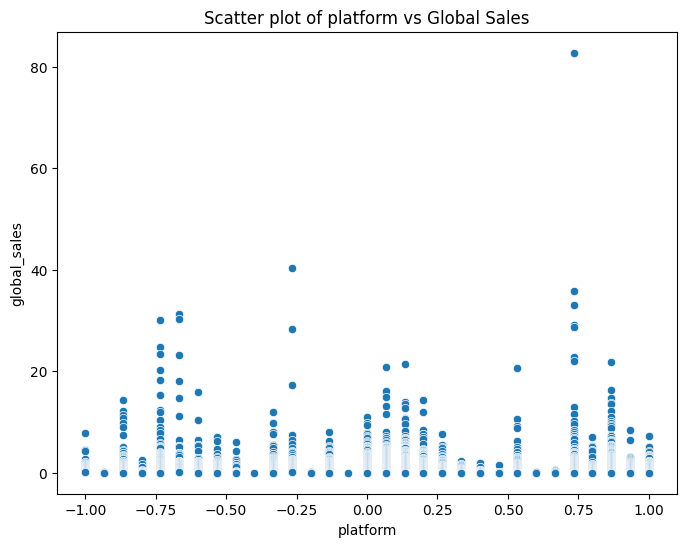

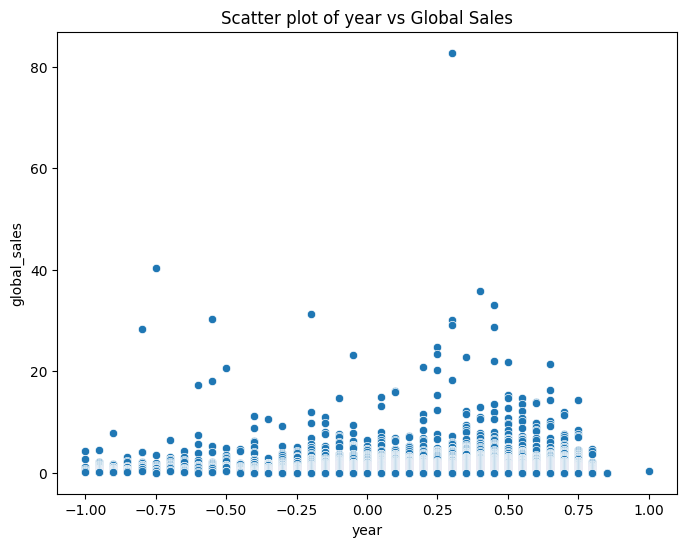

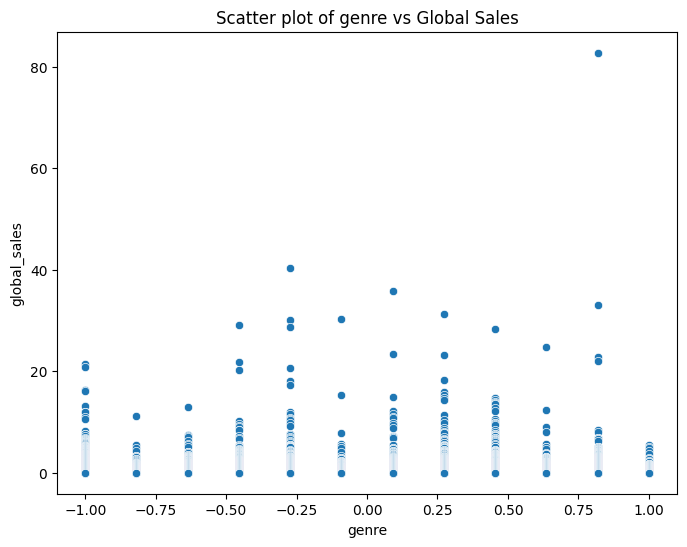

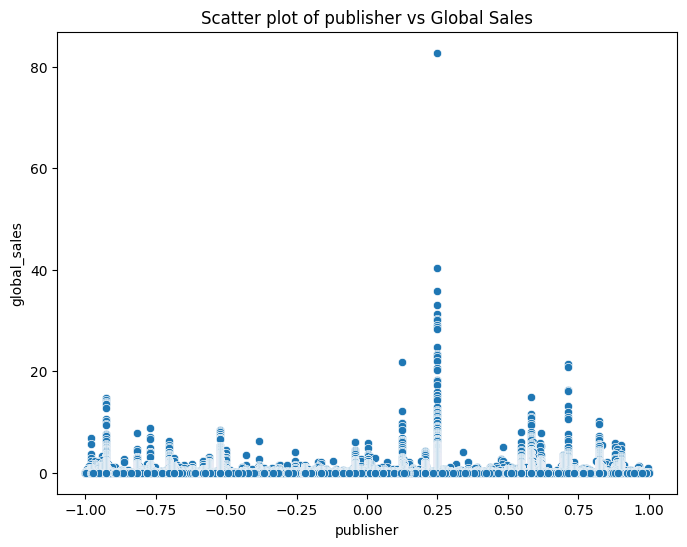

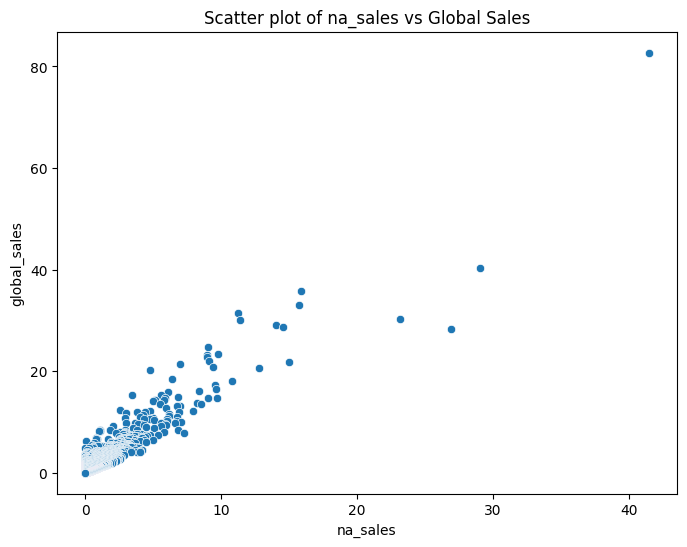

In [171]:
# create a 2D scatter plot to 'eyeball' the relationship between your chosen feature and global_sales
for feature in df_VideoGameCleaned.columns:
    if feature != 'global_sales':
        plt.figure(figsize=(8,6))
        sns.scatterplot(data=df_VideoGameCleaned, x=feature, y='global_sales')
        plt.title(f'Scatter plot of {feature} vs Global Sales')
        plt.show()


In [172]:
# Seperate the Features and the Target
df_tgt = df_VideoGameCleaned['global_sales']
df_feat = df_VideoGameCleaned.drop(columns=['global_sales'])

In [173]:
# Print the feature dataframe
df_feat.head()

,platform,year,genre,publisher,na_sales
0,0.733333,0.30,0.818182,0.248696,41.49
1,-0.266667,-0.75,-0.272727,0.248696,29.08
2,0.733333,0.40,0.090909,0.248696,15.85
3,0.733333,0.45,0.818182,0.248696,15.75
4,-0.666667,-0.20,0.272727,0.248696,11.27


In [174]:
# Print the target dataframe
df_tgt.head()

0    82.74
1    40.24
2    35.82
3    33.00
4    31.37
Name: global_sales, dtype: float64

In [175]:
# use train_test_split to get your dataset ready for training and testing
X_train, X_test, y_train, y_test = train_test_split(df_feat, df_tgt, test_size=0.2, random_state=42)

# print out the shape of the trainig and testing, feature and targets
print('Shape of X_train: ', X_train.shape)
print('Shape of X_test: ', X_test.shape)
print('Shape of y_train: ', y_train.shape)
print('Shape of y_test: ', y_test.shape)

Shape of X_train:  (13032, 5)
Shape of X_test:  (3259, 5)
Shape of y_train:  (13032,)
Shape of y_test:  (3259,)


In [ ]:
# Import the LinearRegression class from sklearn.linear_model
from sklearn.linear_model import LinearRegression
from sklearn.base import clone
import sklearn
print(sklearn.__version__)
# Initalize the LinearRegression object
lr = LinearRegression()
h_coefs = []
h_intercept = 0

#!!! Important !!!
# Fit your Linear Regressor on only ** one ** of the features in your X's, 
# HINT: If you have multiple features in your X_train, select your chosen feature for singular linear regression and make a new dataframe
prev_r2_val = 0
for col in X_train.columns:
    X_train_feature = X_train[[col]]
    X_test_feature = X_test[[col]]
    
    # Fit the model
    lr.fit(X_train_feature, y_train)
    
    # use the model's class function .score to calculate the r^2 value
    r2_value = lr.score(X_test_feature, y_test)
    if prev_r2_val < r2_value or prev_r2_val == 0:
        prev_r2_val = r2_value
        h_coefs = lr.coef_
        h_intercept = lr.intercept_
        # Get your predictions from your fitted model
        y_pred = lr.predict(X_test_feature)
    
    # Print out the r2 value for the linear regressor
    print(f'R^2 value for feature {col}: {r2_value}')

1.7.0
R^2 value for feature platform: 0.0009678408337383537
R^2 value for feature year: 0.00045423123451893144
R^2 value for feature genre: 0.0004951173253666674
R^2 value for feature publisher: -3.824644472416594e-05
R^2 value for feature na_sales: 0.9208878288847482


In [177]:
# Coefficients and intercept (y = wx + b), where w is the weight, or coefficent of x, and b is the y-intercept
print(f'Coefficients: {h_coefs}')
print(f'Intercept: {h_intercept}')

Coefficients: [1.7386314]
Intercept: 0.07732678495789863


In [178]:
# Use a scatter plot to show how the line passes through the dataset
# You can optionally spilt the train and test set by color, and plot the line by passing X_test, and y_pred


### Linear Regression Questions: 

1. What was the final r^2 value of your model? 
2.  What does this tell us? 

- 0.9208878288847482
- This says that we have low variance with this model.
    - While it works, kind of, in this case it is not generally the best good-fit metric we could have used

3. Can we get more performance from this model? 
4. If so, how? If not, why?
- Yes
- We could have included the other sales data features. If we were not required to leave those features out it would be the best correlation we possibly could have

5. Would it be beneficial to perform multiple linear regresssion? I.e. use several features to predict the target?
6. Why?
- No
- With such a strong correlation between one of our features (na_sales) and our target and other would only reduce the correlation coefficients.

7. Why is there one feature in particular that tracks so well with the target, global_sales?
- na_sales is almost certainly a subset of global sales, so it stands to reason that there would be high correlation between that feature and our target

P.S.
- I believe that we are supposed to split the data before preprocessing to not introduce data leakage. Is that true for these examples or am I misunderstanding these preprocessing steps as not being affected?
    - I could see arguments that the data is only scaled on a sole feature basis, but minmax scaling uses the full range of the data so you do get the minimum and maximum values even if those ranges are not reflected after the split

# 2. Multi Classification - Classify the *"Quality"* variable (3~9) for Wine Data
## Use the numeric features in the wine dataset to predict a 'class'
## https://www.kaggle.com/datasets/yasserh/wine-quality-dataset/data

In [179]:
# Load the wine dataset
df_wine = pd.read_csv('wine_data.csv')
df_wine

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
20995,9.7,1.020,0.91,50.00,0.412,114.6,181.7,1.02085,3.30,0.89,12.0,9
20996,10.2,0.610,0.88,53.80,0.250,62.4,204.7,1.02776,3.52,1.14,9.7,9
20997,13.4,0.460,1.04,52.10,0.449,63.0,273.5,1.02618,2.89,1.76,9.3,9
20998,6.6,1.030,1.09,25.30,0.138,179.8,295.0,1.02476,2.94,1.54,12.9,9


In [180]:
# this feature will be our target variable
df_wine.quality.unique()

array([3, 4, 5, 6, 7, 8, 9])

In [181]:
df_wine.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,9.797079,0.774796,0.793870,31.289348,0.200245,129.442333,229.008762,1.009972,3.158712,1.020641,11.291716,6.000000
std,2.413919,0.365015,0.384833,19.015391,0.124933,77.167262,100.183265,0.012032,0.171371,0.408304,1.182198,2.000048
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,7.600000,0.430000,0.410000,9.800000,0.072000,45.000000,150.000000,0.997417,3.030000,0.620000,10.400000,4.000000
50%,10.000000,0.830000,0.870000,37.600000,0.205000,145.800000,240.500000,1.012200,3.150000,1.080000,11.300000,6.000000
75%,11.800000,1.080000,1.110000,46.800000,0.298000,194.325000,311.625000,1.019840,3.270000,1.360000,12.200000,8.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [182]:
y = df_wine.quality
y

0        3
1        3
2        3
3        3
4        3
        ..
20995    9
20996    9
20997    9
20998    9
20999    9
Name: quality, Length: 21000, dtype: int64

In [183]:
X = df_wine.drop('quality', axis=1)
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0
...,...,...,...,...,...,...,...,...,...,...,...
20995,9.7,1.020,0.91,50.00,0.412,114.6,181.7,1.02085,3.30,0.89,12.0
20996,10.2,0.610,0.88,53.80,0.250,62.4,204.7,1.02776,3.52,1.14,9.7
20997,13.4,0.460,1.04,52.10,0.449,63.0,273.5,1.02618,2.89,1.76,9.3
20998,6.6,1.030,1.09,25.30,0.138,179.8,295.0,1.02476,2.94,1.54,12.9


In [184]:
from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler(feature_range=(-1, 1))

X = mm_scaler.fit_transform(X)
X = pd.DataFrame(data=X, columns=df_wine.drop('quality', axis=1).columns)
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,0.289256,-0.333333,-0.204819,-0.950920,-0.784053,-0.937500,-0.811060,-0.472142,-0.178295,-0.606742,-0.710145
1,0.090909,-0.293333,-0.409639,-0.953988,-0.365449,-0.972222,-0.953917,-0.526123,-0.317829,-0.539326,-0.884058
2,-0.404959,0.473333,-1.000000,-0.888037,-0.707641,-0.972222,-0.963134,-0.634085,0.410853,-0.640449,-0.217391
3,0.090909,-0.520000,-0.493976,-0.972393,-0.548173,-0.770833,-0.806452,-0.567766,0.023256,-0.280899,-0.449275
4,-0.256198,0.253333,-0.975904,-0.914110,-0.750831,-0.965278,-0.976959,-0.544631,0.178295,-0.696629,-0.130435
...,...,...,...,...,...,...,...,...,...,...,...
20995,-0.024793,0.253333,0.096386,0.515337,0.338870,-0.211111,-0.190323,0.300945,-0.100775,-0.247191,0.159420
20996,0.057851,-0.293333,0.060241,0.631902,-0.199336,-0.573611,-0.084332,0.567380,0.240310,0.033708,-0.507246
20997,0.586777,-0.493333,0.253012,0.579755,0.461794,-0.569444,0.232719,0.506458,-0.736434,0.730337,-0.623188
20998,-0.537190,0.266667,0.313253,-0.242331,-0.571429,0.241667,0.331797,0.451706,-0.658915,0.483146,0.420290


In [185]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle=True, random_state=1)

print('Shape of X_train: ', X_train.shape)
print('Shape of X_test: ',X_test.shape)
print('Shape of y_train: ',y_train.shape)
print('Shape of y_test: ',y_test.shape)

Shape of X_train:  (16800, 11)
Shape of X_test:  (4200, 11)
Shape of y_train:  (16800,)
Shape of y_test:  (4200,)


In [186]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))

Accuracy: 0.6261904761904762
              precision    recall  f1-score   support

           3       0.59      0.65      0.62       633
           4       0.59      0.58      0.59       593
           5       0.77      0.62      0.69       611
           6       0.68      0.74      0.71       594
           7       0.75      0.51      0.60       612
           8       0.56      0.59      0.58       575
           9       0.53      0.69      0.60       582

    accuracy                           0.63      4200
   macro avg       0.64      0.63      0.63      4200
weighted avg       0.64      0.63      0.63      4200



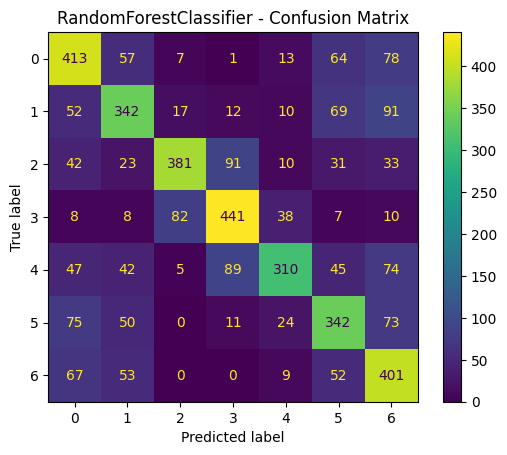

In [187]:
# Calculate the confusion matrix by passing the true y lables, and the predicted y lables
cm = confusion_matrix(y_test, y_pred)

# Use the ConfusionMatrixDisplay from skelearn to get a quick and easy graph
ConfusionMatrixDisplay(cm).plot()
plt.title('RandomForestClassifier - Confusion Matrix')
plt.show()

### Multiclass Classifier Questions
1. Summarize the steps I took to create this multiclass classifier

   - ID target
   - preprocess
   - test-train-split
   - fit
   - predict
2. Interpret the Confusion Matrix and Classification Report
   - precision, recall, and f1-score are nearly the same score
      - This makes the model very centered and not focused on a certain single attribute
   - It looks like the corners of our confusion matrix are more highly correlated rather than a nice curve/mountain across the diagonal
      - I would assume this due to quality being our target, it would make sense that the closer nubers in quality are more easily mistaken for each other based on the incremental values of qualities

3. How could we improve this model? Be specific.
   - Split training and test data before doing any scaling
   - Plot out and visualize data before deciding on preprocessing models to use on our dataset
   - test other classification models
   - use a CV to test multipletest/training sets and hyperparameters
4. What other models might be good to solve this problem?
   - Since quality is incremental by nature, I would try multiple linear regression and all our values are numeric which makes it a little easier on linear models to interpret
   - Decision trees and Gradient boosting could work as well to allow slight changes in variables to more gradually effect the outcome
      - Decision trees also allow the extremes to be taken into account lead away from higher quality values
      - i.e. high and low alcohol content would both be bad for wine, akin to grape juice/everclear in that neither of those are good wine
   - KNNeighbors could also allow high correlation values to more accurately push the best qualities up as better correlators
5. What are the potential downsides of solving this as a classification problem?
   - I think I touched on this but since quality is incremental its easier to allow lines to be drawn along the data and regression is a little easier to represent that
6. What are the benifits of solving this as a classification problem?
   - Allows higher correlation between the different features to be propped up and given better weights than focus on a more average grouping of the targets as regressions like to do
   

# 3. Binary Classification - Cure The Princess
## https://www.kaggle.com/datasets/unmoved/cure-the-princess

In [198]:
df_Quest = pd.read_csv('Cure_the_princess.csv')
df_Quest

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang,Cured
0,2.4,18.7,18.4,27.9,7.9,9.6,18.3,13.2,2.5,26.0,10.5,26.2,12.5,0
1,2.1,6.0,15.0,13.3,15.6,13.1,11.0,5.0,7.2,26.0,1.5,13.3,6.2,0
2,17.2,13.9,23.8,6.8,10.7,15.8,19.4,2.7,15.4,21.2,11.1,16.6,11.4,1
3,8.4,9.7,6.8,26.9,4.6,29.1,14.6,19.7,18.0,20.8,13.6,13.9,8.1,1
4,22.1,10.8,16.4,10.5,22.0,23.4,2.6,18.2,23.8,11.3,5.5,16.8,16.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,9.4,2.2,15.8,5.9,29.7,18.7,11.5,13.1,15.3,22.5,10.1,4.7,13.8,0
2334,12.1,7.6,20.6,5.3,18.9,19.1,9.4,11.9,21.8,12.0,26.7,8.4,24.4,1
2335,15.2,33.2,7.2,14.5,16.0,16.7,1.2,32.5,34.5,25.9,3.9,18.0,19.2,1
2336,2.0,17.0,33.2,13.2,29.1,35.5,19.7,30.3,30.7,4.3,15.7,20.5,2.1,1


In [199]:
# Envoke the describe command on the dataset
df_Quest.describe()

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang,Cured
count,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000,2338.000000
mean,15.365697,10.946749,16.115654,13.627973,15.069504,14.157271,12.328914,14.911206,16.871685,14.890590,10.916125,15.371600,12.084003,0.496578
std,8.669969,7.225162,8.372518,7.545244,8.349340,7.831476,7.709753,8.132678,9.579027,8.014197,7.045195,8.559139,8.047540,0.500095
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,8.500000,5.300000,9.600000,7.600000,8.625000,7.900000,6.325000,8.400000,8.900000,8.800000,5.200000,8.800000,5.600000,0.000000
50%,14.700000,9.500000,15.800000,13.100000,14.500000,13.500000,11.200000,14.400000,16.300000,14.400000,9.700000,14.800000,10.500000,0.000000
75%,21.300000,15.575000,22.000000,19.000000,20.700000,19.500000,16.900000,20.500000,24.000000,20.400000,15.375000,21.100000,17.275000,1.000000
max,42.100000,34.100000,40.800000,35.800000,40.400000,37.800000,37.300000,39.400000,44.800000,39.500000,33.700000,42.000000,37.800000,1.000000


Text(0.5, 1.0, 'Correlation Heatmap for Quest Dataset')

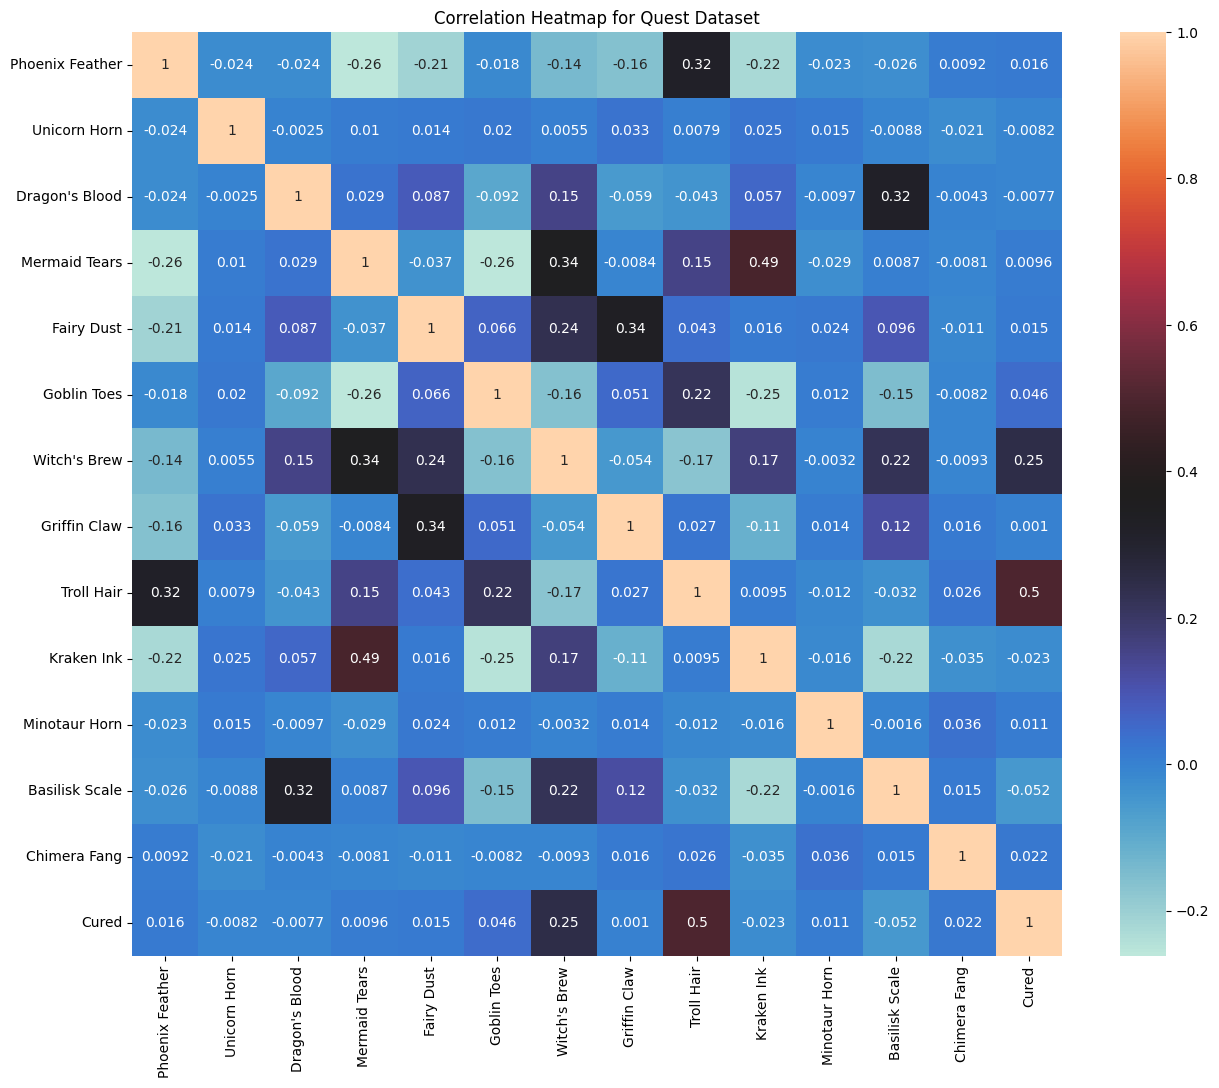

In [270]:
# Plot the values from the .corr() command on a heat map
df_Quest_corr = df_Quest.corr()
plt.figure(figsize=(15,12))
sns.heatmap(df_Quest_corr, annot=True, cmap='icefire')
plt.title('Correlation Heatmap for Quest Dataset')


In [271]:
# Seperate your ingredients (features) from the outcome (target)
X = df_Quest.drop('Cured', axis=1)
X

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang
0,2.4,18.7,18.4,27.9,7.9,9.6,18.3,13.2,2.5,26.0,10.5,26.2,12.5
1,2.1,6.0,15.0,13.3,15.6,13.1,11.0,5.0,7.2,26.0,1.5,13.3,6.2
2,17.2,13.9,23.8,6.8,10.7,15.8,19.4,2.7,15.4,21.2,11.1,16.6,11.4
3,8.4,9.7,6.8,26.9,4.6,29.1,14.6,19.7,18.0,20.8,13.6,13.9,8.1
4,22.1,10.8,16.4,10.5,22.0,23.4,2.6,18.2,23.8,11.3,5.5,16.8,16.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,9.4,2.2,15.8,5.9,29.7,18.7,11.5,13.1,15.3,22.5,10.1,4.7,13.8
2334,12.1,7.6,20.6,5.3,18.9,19.1,9.4,11.9,21.8,12.0,26.7,8.4,24.4
2335,15.2,33.2,7.2,14.5,16.0,16.7,1.2,32.5,34.5,25.9,3.9,18.0,19.2
2336,2.0,17.0,33.2,13.2,29.1,35.5,19.7,30.3,30.7,4.3,15.7,20.5,2.1


In [272]:
# Seperate out Cured (target)
y = df_Quest.Cured
y

0       0
1       0
2       1
3       1
4       0
       ..
2333    0
2334    1
2335    1
2336    1
2337    1
Name: Cured, Length: 2338, dtype: int64

In [273]:
# Import MinMaxScaler from sklearn
from sklearn.preprocessing import MinMaxScaler

# Initalize the MinMaxScaler with feature_range=(-1, 1)
mm_scaler = MinMaxScaler(feature_range=(-1, 1))

# Transform the Ingredients (X) using the MinMaxScaler
X = mm_scaler.fit_transform(X)


In [274]:
# Seperate the training and testing data using the train_test_split function
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=691)

# print the shape of your datasets
print('Shape of X_train: ',X_train.shape)
print('Shape of X_test: ',X_test.shape)
print('Shape of y_train: ',y_train.shape)
print('Shape of y_test: ',y_test.shape)

Shape of X_train:  (1870, 13)
Shape of X_test:  (468, 13)
Shape of y_train:  (1870,)
Shape of y_test:  (468,)


In [279]:
# Import Statements
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score, RocCurveDisplay

# Initialize and train a LogisticRegressior
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Make class predictions
y_pred = lr.predict(X_test)

# Make probability predicitons, named y_proba
y_proba = lr.predict_proba(X_test)
print(y_proba)
# Evaluate accuracy using the accuracy_score function from sklearn
accuracy = accuracy_score(y_test, y_pred)

# print the classification_report for your logistic regressor
print(classification_report(y_test, y_pred))


[[7.69488873e-01 2.30511127e-01]
 [9.15175075e-01 8.48249247e-02]
 [5.30538687e-01 4.69461313e-01]
 [1.48046393e-01 8.51953607e-01]
 [8.23945672e-02 9.17605433e-01]
 [9.46422225e-01 5.35777755e-02]
 [1.20573028e-01 8.79426972e-01]
 [4.01116663e-01 5.98883337e-01]
 [9.86328666e-01 1.36713338e-02]
 [7.66531405e-01 2.33468595e-01]
 [4.02921023e-01 5.97078977e-01]
 [9.84247970e-01 1.57520295e-02]
 [1.23969610e-02 9.87603039e-01]
 [1.74970188e-02 9.82502981e-01]
 [2.42903780e-01 7.57096220e-01]
 [6.05256971e-02 9.39474303e-01]
 [1.28077557e-01 8.71922443e-01]
 [2.98894466e-03 9.97011055e-01]
 [8.70268671e-01 1.29731329e-01]
 [1.55407755e-01 8.44592245e-01]
 [3.91984585e-01 6.08015415e-01]
 [4.86403022e-02 9.51359698e-01]
 [1.12243844e-01 8.87756156e-01]
 [7.39374872e-02 9.26062513e-01]
 [4.30881425e-02 9.56911858e-01]
 [3.14509940e-01 6.85490060e-01]
 [6.63811353e-02 9.33618865e-01]
 [9.52485160e-01 4.75148403e-02]
 [4.20556246e-01 5.79443754e-01]
 [8.00325228e-01 1.99674772e-01]
 [8.093670

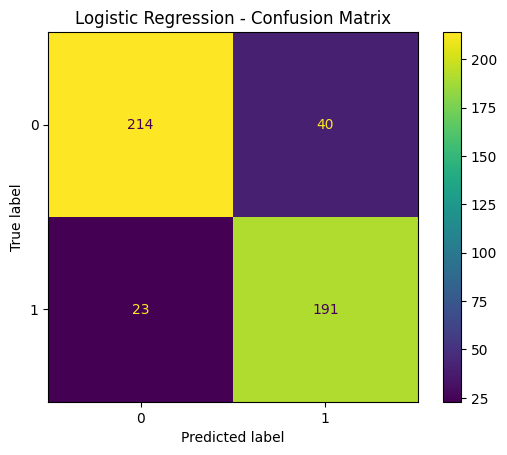

In [280]:
# Create a confusion matrix using the confusion_matrix function, and save it to a variable named cm
cm = confusion_matrix(y_test, y_pred)

# Using ConfusionMatrixDisplay pass your variable named cm that you just created
ConfusionMatrixDisplay(cm).plot()
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [281]:
# use the (receiver operating characteristic) roc_curve function to calculate the falsepositive_rate, truepositive_rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:,1])

# use the roc_auc_score to calculate the Area Under the Curve (AUC)
auc = roc_auc_score(y_test, y_proba[:,1])

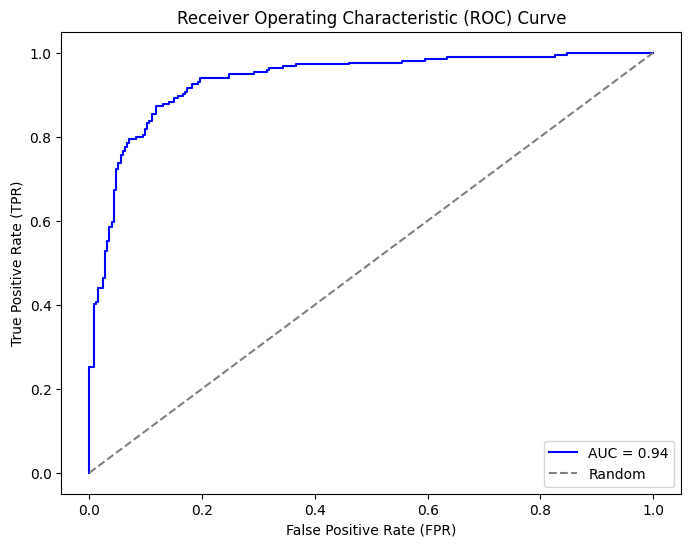

In [282]:
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(False)
plt.show()

### Cure the Princess
1. What ingredients should you use?
    - Troll hair, Witch's Brew, Goblin Toes
2. How can you be certain that these are the correct ingredients?
    - These are the top 3 ingredients with the highest correlation values
3. Can you determine the **exact ratio** of ingredients that maximizes the princess' survival?
    - Using the correlation values you can do:
        - 1/2 Troll Hair
        - 1/4 Witch's Brew
        - 1/4 Goblin Toes
4. Should attempt to convience the king that you know to cure the princess, or should you conduct more experiments?
    - Conduct more experiments
5. *Assuming* that you are ready to cure the princess, convince the king.
    - With a high AUC we can say that the model trends well with our dataset
    - Ratios are provided via the correlation, so we can assume a good chance of a cure based on those ratios
    - With more conducted experiments we can show our ratios have a high correlation with the model's predictions